In [47]:
# Retrieve csv file from google drive by mapping the folder from google drive. Must be done each time session expires.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
%cd data/

data/


In [73]:
# Read the data
import pandas as pd
credit = pd.read_csv("credit_card_default_courseware-2.csv")

In [50]:
credit.shape

(30000, 25)

In [51]:
credit.head()

              ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE PAY_1  PAY_2  \
0  798fc410-45c1      20000    2          2         1   24     2      2   
1  8a8c8f3b-8eb4     120000    2          2         2   26    -1      2   
2  85698822-43f5      90000    2          2         2   34     0      0   
3  0737c11b-be42      50000    2          2         1   37     0      0   
4  3b7f77cc-dbc0      50000    1          2         1   57    -1      0   

   PAY_3  PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
0     -1     -1  ...          0          0          0         0       689   
1      0      0  ...       3272       3455       3261         0      1000   
2      0      0  ...      14331      14948      15549      1518      1500   
3      0      0  ...      28314      28959      29547      2000      2019   
4     -1      0  ...      20940      19146      19131      2000     36681   

   PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  
0         0   

In [82]:
# Drop ID to avoid encoding high cardinality column
credit = credit.drop('ID', axis=1)

In [53]:
credit.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [60]:
# Check Data Types
credit.dtypes

LIMIT_BAL                      int64
SEX                            int64
EDUCATION                      int64
MARRIAGE                       int64
AGE                            int64
PAY_1                         object
PAY_2                          int64
PAY_3                          int64
PAY_4                          int64
PAY_5                          int64
PAY_6                          int64
BILL_AMT1                      int64
BILL_AMT2                      int64
BILL_AMT3                      int64
BILL_AMT4                      int64
BILL_AMT5                      int64
BILL_AMT6                      int64
PAY_AMT1                       int64
PAY_AMT2                       int64
PAY_AMT3                       int64
PAY_AMT4                       int64
PAY_AMT5                       int64
PAY_AMT6                       int64
default payment next month     int64
dtype: object

In [75]:
print(credit['PAY_1'].value_counts(dropna=False))

PAY_1
0                13402
-1                5047
1                 3261
Not available     3021
-2                2476
2                 2378
3                  292
4                   63
5                   23
8                   17
6                   11
7                    9
Name: count, dtype: int64


In [76]:
# Replace "Not Available" with most common payment types since dropping it would remove about 10% of the data
credit['PAY_1'] = credit['PAY_1'].replace('Not available', np.nan)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
credit['PAY_1'] = imputer.fit_transform(credit[['PAY_1']]).ravel()

In [78]:
# Convert Pay_1 from object to numeric so we can scale the data
credit['PAY_1'] = pd.to_numeric(credit['PAY_1'])

In [79]:
# Percentage distribution
credit['default payment next month'].value_counts(normalize=True) * 100

default payment next month
0    78.126667
1    21.873333
Name: proportion, dtype: float64

In [80]:
# Calculate correlations with the target
correlations = credit.corr(numeric_only=True)['default payment next month']

# Sort from strongest positive to strongest negative
correlations.sort_values(ascending=False)

default payment next month    1.000000
PAY_1                         0.308162
PAY_2                         0.262028
PAY_3                         0.233518
PAY_4                         0.215199
PAY_5                         0.201941
PAY_6                         0.184802
EDUCATION                     0.040400
AGE                           0.032733
BILL_AMT6                    -0.001904
BILL_AMT5                    -0.002967
BILL_AMT4                    -0.006448
MARRIAGE                     -0.007812
BILL_AMT3                    -0.010439
BILL_AMT2                    -0.010610
BILL_AMT1                    -0.015738
SEX                          -0.020674
PAY_AMT6                     -0.051121
PAY_AMT5                     -0.053019
PAY_AMT3                     -0.054009
PAY_AMT4                     -0.054781
PAY_AMT2                     -0.056567
PAY_AMT1                     -0.070883
LIMIT_BAL                    -0.144928
Name: default payment next month, dtype: float64

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = credit.drop(['default payment next month'],axis = 1)
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

y = credit[['default payment next month']]

In [92]:
# Split into training and test data - 80/20 split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [93]:
# Import the model, create classifer object, fit the model to the data

from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
logreg = LogisticRegression(max_iter = 200)

# fit the model with data
logreg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=200)

In [94]:
coef = pd.DataFrame(logreg.coef_[0], index = X.columns,columns=['Coefficients'])

In [95]:
import numpy as np
df = pd.DataFrame(np.exp(logreg.coef_)[0], index = X_train.columns,columns = ['Odds'])
df.sort_values(by=['Odds'], ascending = False)

               Odds
PAY_1      1.741710
BILL_AMT3  1.208307
AGE        1.176004
PAY_2      1.158148
BILL_AMT2  1.145848
PAY_3      1.103590
BILL_AMT5  1.065743
PAY_5      1.039819
PAY_4      1.026902
PAY_6      1.026404
BILL_AMT4  1.018512
BILL_AMT6  1.012204
SEX        0.986960
MARRIAGE   0.985132
PAY_AMT5   0.983325
PAY_AMT6   0.947041
PAY_AMT3   0.943489
EDUCATION  0.941469
LIMIT_BAL  0.932903
PAY_AMT4   0.925049
PAY_AMT2   0.785274
PAY_AMT1   0.754881
BILL_AMT1  0.608306

In [96]:
# Evaluate Logistic Regression on the test set
y_pred=logreg.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 1, 0])

In [97]:
import sklearn.metrics as metrics
print("Accuracy::{:.3f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy::0.818


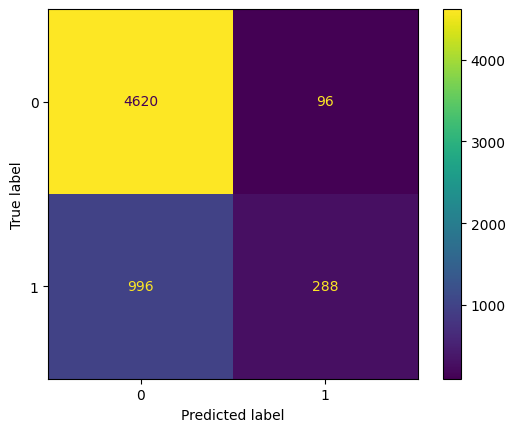

In [98]:
# Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=logreg.classes_)
disp.plot()
plt.show()

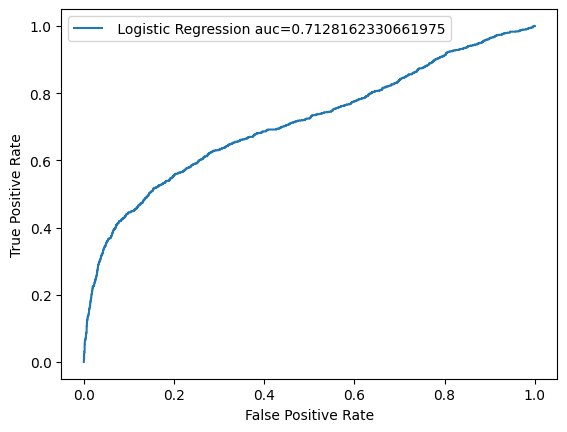

In [99]:
# ROC-AUC Curve

from matplotlib import pyplot
#keep probabilities for the positive outcome only
y_pred_proba = logreg.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
pyplot.plot(fpr,tpr,label=" Logistic Regression auc="+str(auc))
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
#plt.legend(loc=4)
# show the legend
pyplot.legend()
plt.show()

Create Decsion Tree

In [100]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state = 0)

In [101]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [102]:
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))

Accuracy on training set: 1.000


In [103]:
y_pred = tree.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy on test set: {:.3f}".format(accuracy_score(y_pred, y_test)))

Accuracy on test set: 0.739


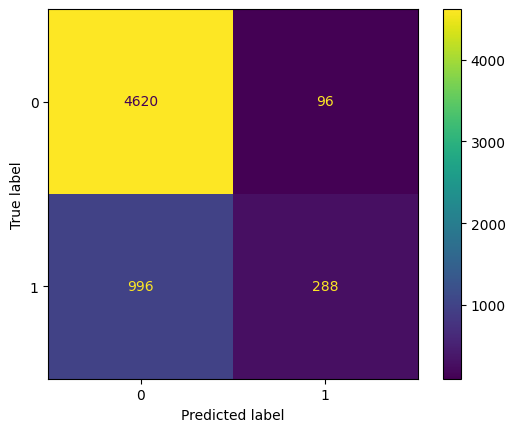

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=tree.classes_)
disp.plot()
plt.show()

In [105]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree, X, y, cv= 5)
print("Accuracy scores of each fold: {}".format(scores))

#A common way to summarize the cross-validation accuracy is to compute the mean:
print("Average cross-validation score: {:.2f}".format(scores.mean()))

Accuracy scores of each fold: [0.71716667 0.71516667 0.73266667 0.73016667 0.72783333]
Average cross-validation score: 0.72


In [106]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

y_rf_pred = forest.predict(X_test)
print("Random Forest Accuracy on test set: {:.3f}".format(accuracy_score(y_test, y_rf_pred)))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy on test set: 0.824


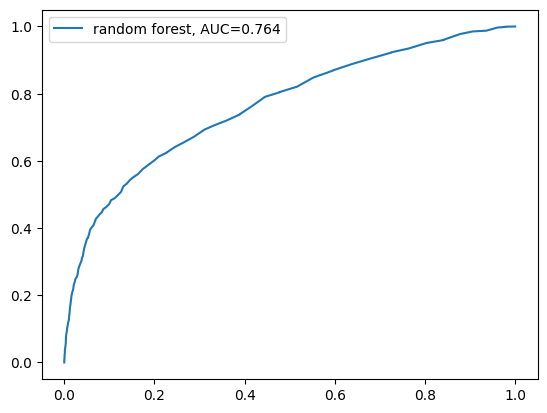

In [107]:
y_pred_prob_rf = forest.predict_proba(X_test)[:,1]
fpr4, tpr4, thresholds4 = metrics.roc_curve(y_test, y_pred_prob_rf)
auc_tree = round(metrics.roc_auc_score(y_test, y_pred_prob_rf), 3)
plt.plot(fpr4,tpr4,label="random forest, AUC="+str(auc_tree))
plt.legend()

In [108]:
importances = forest.feature_importances_

df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
df = df.sort_values('importance')
print(df)

      feature  importance
1         SEX    0.012865
3    MARRIAGE    0.014624
8       PAY_4    0.018078
10      PAY_6    0.019008
2   EDUCATION    0.020603
9       PAY_5    0.022420
7       PAY_3    0.030802
20   PAY_AMT4    0.042449
21   PAY_AMT5    0.043704
19   PAY_AMT3    0.045653
18   PAY_AMT2    0.046789
22   PAY_AMT6    0.047384
14  BILL_AMT4    0.050278
17   PAY_AMT1    0.050544
16  BILL_AMT6    0.050612
15  BILL_AMT5    0.050780
13  BILL_AMT3    0.052192
6       PAY_2    0.053105
12  BILL_AMT2    0.053526
0   LIMIT_BAL    0.059854
11  BILL_AMT1    0.060290
4         AGE    0.066347
5       PAY_1    0.088094
